In [1]:
pip install medmnist

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from medmnist import DermaMNIST

# Descarga automáticamente
train_dataset = DermaMNIST(split='train', download=True)
val_dataset = DermaMNIST(split='val', download=True)
test_dataset = DermaMNIST(split='test', download=True)

print(len(train_dataset))

7007


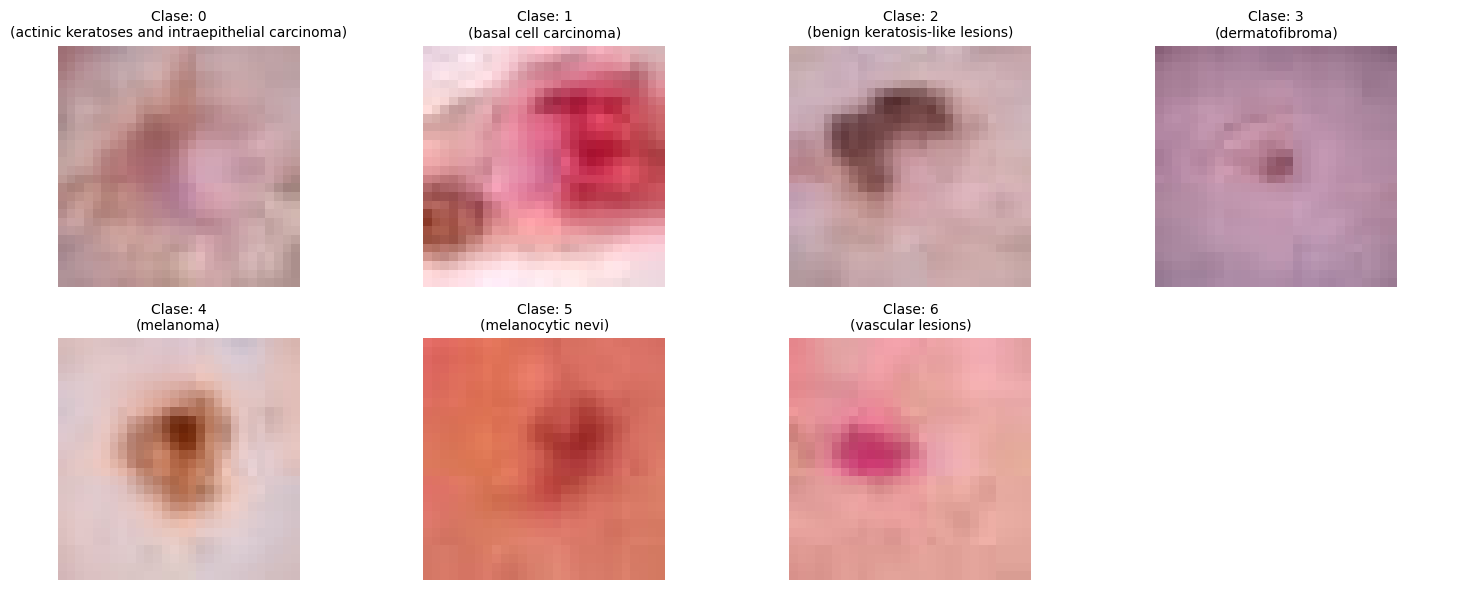

In [ ]:
import matplotlib.pyplot as plt

# MedMNIST guarda la metadata del dataset
class_dict = train_dataset.info['label']

# Diccionario para guardar temporalmente una imagen de cada clase
imagenes_por_clase = {}

# Recorremos el dataset hasta encontrar un ejemplo de cada una de las 7 clases
for img, label in train_dataset:
    label_idx = label[0].item() if hasattr(label[0], 'item') else label[0]
    
    # Si esta clase aún no está en nuestro diccionario, la guardamos
    if label_idx not in imagenes_por_clase:
        imagenes_por_clase[label_idx] = img
        
    # Si ya recolectamos las 7 clases distintas, detenemos el bucle para ahorrar tiempo
    if len(imagenes_por_clase) == 7:
        break

# Creamos una cuadrícula de 2 filas y 4 columnas
fig, axes = plt.subplots(2, 4, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    if i < 7: # Solo tenemos 7 clases (del 0 al 6)
        img_visual = imagenes_por_clase[i]
        class_name = class_dict[str(i)]
        
        # Como es un objeto PIL Image, Matplotlib lo dibuja directo
        ax.imshow(img_visual)
        ax.set_title(f"Clase: {i}\n({class_name})", fontsize=10)
    
    # Apagamos los bordes y ejes para todos los cuadros
    ax.axis('off')

plt.tight_layout()
plt.show()

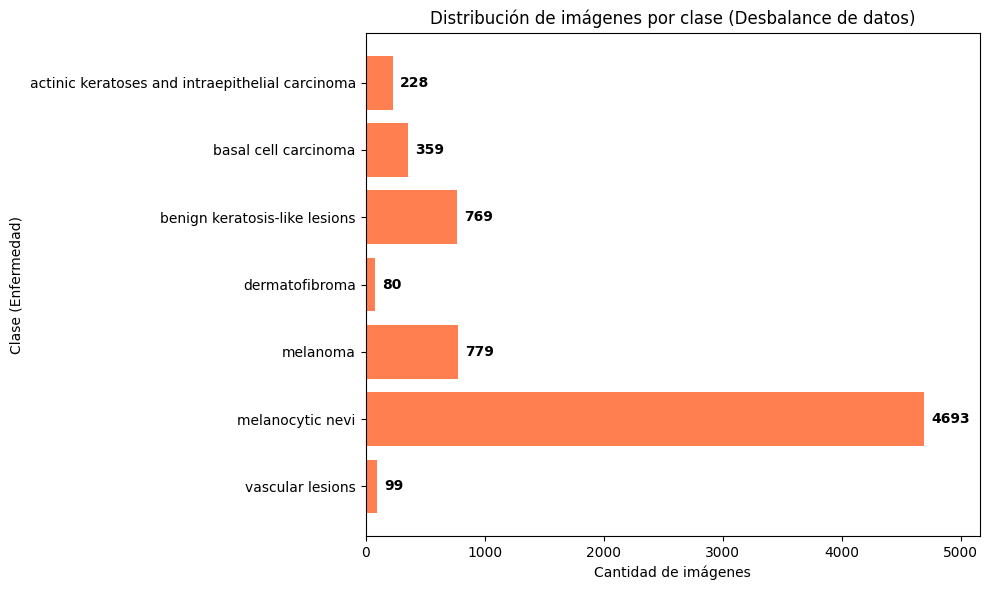

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Aseguramos que class_dict esté definido
class_dict = train_dataset.info['label']

# Extraemos todas las etiquetas del dataset de entrenamiento
labels = [label[0] for img, label in train_dataset]

# Contamos cuántas imágenes hay por clase
clases_unicas, conteos = np.unique(labels, return_counts=True)
nombres_clases = [class_dict[str(c)] for c in clases_unicas]

# Graficamos el desbalance de forma horizontal
plt.figure(figsize=(10, 6))

barras = plt.barh(nombres_clases, conteos, color='coral')
plt.bar_label(barras, padding=5, color='black', fontweight='bold')

plt.title('Distribución de imágenes por clase (Desbalance de datos)')
plt.xlabel('Cantidad de imágenes')
plt.ylabel('Clase (Enfermedad)')
plt.gca().invert_yaxis() # Mantiene el orden original de las clases de arriba a abajo

plt.margins(x=0.1) 

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

# Obtenemos la información de las etiquetas del dataset
info = train_dataset.info
labels = info['label']

# Creamos un DataFrame para visualizarlo de forma ordenada
categories_df = pd.DataFrame(list(labels.items()), columns=['ID', 'Categoría'])

print("Categorías disponibles en DermaMNIST:")
display(categories_df)

Categorías disponibles en DermaMNIST:


,ID,Categoría
0,0,actinic keratoses and intraepithelial carcinoma
1,1,basal cell carcinoma
2,2,benign keratosis-like lesions
3,3,dermatofibroma
4,4,melanoma
5,5,melanocytic nevi
6,6,vascular lesions


In [ ]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST

# 1. Definimos una transformación básica: convertir las imágenes a tensores
data_transform = transforms.Compose([
    transforms.ToTensor()
])

# 2. Volvemos a cargar los datasets, pero ahora aplicando la transformación
train_dataset = DermaMNIST(split='train', transform=data_transform, download=True)
val_dataset = DermaMNIST(split='val', transform=data_transform, download=True)
test_dataset = DermaMNIST(split='test', transform=data_transform, download=True)

# 3. Creamos los DataLoaders
# Mezclamos (shuffle=True) los datos de entrenamiento
BATCH_SIZE = 32
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Lotes de entrenamiento: {len(train_loader)}")
print(f"Lotes de validación: {len(val_loader)}")
print(f"Lotes de prueba: {len(test_loader)}")

Lotes de entrenamiento: 219
Lotes de validación: 32
Lotes de prueba: 63


In [7]:
# Obtenemos un lote de prueba del DataLoader de entrenamiento
imagenes_prueba, etiquetas_prueba = next(iter(train_loader))

# Imprimimos la forma del tensor de las imágenes
print(f"Forma del lote (Batch shape): {imagenes_prueba.shape}")

# Explicación de la salida:
# El formato en PyTorch es [Batch_size, Canales, Alto, Ancho]
# Debería imprimir: torch.Size([32, 3, 28, 28])
# Esto confirma que estamos procesando 32 imágenes por lote, a color (3 canales RGB), de 28x28 píxeles.

Forma del lote (Batch shape): torch.Size([32, 3, 28, 28])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# Configurar el dispositivo (GPU si está disponible, si no CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# 1. Cargar la arquitectura ResNet18 con pesos PRE-ENTRENADOS (Fine-Tuning)
# Usamos los pesos de ImageNet que es el estándar de la industria
modelo = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. Modificar la última capa (Clasificador)
# ResNet viene configurado para 1000 clases. DermaMNIST tiene 7.
# Al cambiar esta capa, sus pesos se inicializan desde cero, mientras el resto de la red mantiene el conocimiento previo.
num_features = modelo.fc.in_features
modelo.fc = nn.Linear(num_features, 7)

# Enviar el modelo a la tarjeta gráfica o procesador
modelo = modelo.to(device)

# 3. Definir Función de Pérdida y Optimizador
criterio = nn.CrossEntropyLoss()
# Usamos un learning rate pequeño (0.001) típico en fine-tuning para no destruir los pesos pre-entrenados
optimizador = optim.Adam(modelo.parameters(), lr=0.001)

Usando dispositivo: cpu


In [ ]:
import time
import copy # Importante para hacer una copia de los mejores pesos
import matplotlib.pyplot as plt
import torch

historial_train_loss, historial_val_loss = [], []
historial_train_acc, historial_val_acc = [], []

num_epocas = 20

# --- VARIABLES PARA EARLY STOPPING ---
mejor_val_acc = 0.0
mejores_pesos_modelo = copy.deepcopy(modelo.state_dict()) # Guardará la mejor versión
paciencia = 5 # Cuántas épocas esperaremos si no hay mejora antes de cortar
epocas_sin_mejorar = 0

for epoca in range(num_epocas):
    inicio_tiempo = time.time()
    
    # --- FASE DE ENTRENAMIENTO ---
    modelo.train()
    train_loss, train_correctos, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.squeeze().to(device)
        
        optimizador.zero_grad()
        outputs = modelo(inputs)
        loss = criterio(outputs, labels)
        loss.backward()
        optimizador.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicciones = torch.max(outputs, 1)
        train_correctos += torch.sum(predicciones == labels.data)
        total_train += labels.size(0)
        
    acc_train = (train_correctos.double() / total_train).item()
    loss_train_promedio = train_loss / total_train
    
    # --- FASE DE VALIDACIÓN ---
    modelo.eval()
    val_loss, val_correctos, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.squeeze().to(device)
            outputs = modelo(inputs)
            loss = criterio(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicciones = torch.max(outputs, 1)
            val_correctos += torch.sum(predicciones == labels.data)
            total_val += labels.size(0)
            
    acc_val = (val_correctos.double() / total_val).item()
    loss_val_promedio = val_loss / total_val
    
    historial_train_loss.append(loss_train_promedio)
    historial_val_loss.append(loss_val_promedio)
    historial_train_acc.append(acc_train)
    historial_val_acc.append(acc_val)
    
    tiempo_epoca = time.time() - inicio_tiempo
    
    # Imprimir resultados
    print(f'Época {epoca+1}/{num_epocas} | Tiempo: {tiempo_epoca:.0f}s | Train Acc: {acc_train:.4f} | Val Acc: {acc_val:.4f}')
    
    # ==========================================
    # LÓGICA DE EARLY STOPPING Y CHECKPOINTING
    # ==========================================
    if acc_val > mejor_val_acc:
        mejor_val_acc = acc_val
        # Si rompimos el récord, hacemos una copia de los pesos actuales
        mejores_pesos_modelo = copy.deepcopy(modelo.state_dict())
        epocas_sin_mejorar = 0
        print(f"  -> ¡Nuevo récord! Modelo guardado. (Val Acc: {mejor_val_acc:.4f})")
    else:
        epocas_sin_mejorar += 1
        print(f"  -> Sin mejoras. Paciencia: {epocas_sin_mejorar}/{paciencia}")
        
        if epocas_sin_mejorar >= paciencia:
            print("-" * 40)
            print(f"Early Stopping activado. El modelo dejó de aprender en la época {epoca+1}.")
            break

# Al finalizar el bucle, le devolvemos al modelo los pesos de su mejor época
modelo.load_state_dict(mejores_pesos_modelo)
print("=" * 40)
print(f"Entrenamiento finalizado. Se restauró el modelo con el mejor Val Acc: {mejor_val_acc:.4f}")

Época 1/20 | Tiempo: 73s | Train Acc: 0.6930 | Val Acc: 0.7198
  -> ¡Nuevo récord! Modelo guardado. (Val Acc: 0.7198)
Época 2/20 | Tiempo: 80s | Train Acc: 0.7211 | Val Acc: 0.7398
  -> ¡Nuevo récord! Modelo guardado. (Val Acc: 0.7398)
Época 3/20 | Tiempo: 78s | Train Acc: 0.7274 | Val Acc: 0.7139
  -> Sin mejoras. Paciencia: 1/5
Época 4/20 | Tiempo: 79s | Train Acc: 0.7267 | Val Acc: 0.7378
  -> Sin mejoras. Paciencia: 2/5
Época 5/20 | Tiempo: 79s | Train Acc: 0.7313 | Val Acc: 0.6839
  -> Sin mejoras. Paciencia: 3/5
Época 6/20 | Tiempo: 75s | Train Acc: 0.7367 | Val Acc: 0.7488
  -> ¡Nuevo récord! Modelo guardado. (Val Acc: 0.7488)
Época 7/20 | Tiempo: 92s | Train Acc: 0.7418 | Val Acc: 0.6301
  -> Sin mejoras. Paciencia: 1/5
Época 8/20 | Tiempo: 104s | Train Acc: 0.7578 | Val Acc: 0.7248
  -> Sin mejoras. Paciencia: 2/5
Época 9/20 | Tiempo: 92s | Train Acc: 0.7667 | Val Acc: 0.7587
  -> ¡Nuevo récord! Modelo guardado. (Val Acc: 0.7587)
Época 10/20 | Tiempo: 94s | Train Acc: 0.7759 |

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Preparar listas para guardar las verdaderas etiquetas y las predicciones
y_verdadero = []
y_predicho = []
y_probabilidades = [] # Necesario para el AUC-ROC

modelo.eval()

# 2. Recorrer el DataLoader de Validación (sin calcular gradientes)
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.squeeze().to(device)
        
        # Obtener las salidas del modelo (logits)
        outputs = modelo(inputs)
        
        # Convertir las salidas a probabilidades usando Softmax
        probabilidades = F.softmax(outputs, dim=1)
        
        # Obtener la clase predicha (la de mayor probabilidad)
        _, predicciones = torch.max(outputs, 1)
        
        # Guardar en las listas (enviando los tensores de vuelta a la CPU)
        y_verdadero.extend(labels.cpu().numpy())
        y_predicho.extend(predicciones.cpu().numpy())
        y_probabilidades.extend(probabilidades.cpu().numpy())

# Convertir a arreglos de NumPy para usar con scikit-learn
y_verdadero = np.array(y_verdadero)
y_predicho = np.array(y_predicho)
y_probabilidades = np.array(y_probabilidades)

# ==========================================
# CÁLCULO DE MÉTRICAS
# ==========================================

# Accuracy General
accuracy = accuracy_score(y_verdadero, y_predicho)

# Precisión, Recall y F1-Score (Macro)
precision_macro = precision_score(y_verdadero, y_predicho, average='macro', zero_division=0)
f1_macro = f1_score(y_verdadero, y_predicho, average='macro', zero_division=0)

# Recall específico para Melanoma (Clase 4 en DermaMNIST)
# El average='none' devuelve el recall para cada una de las 7 clases, tomamos el índice 4
recalls_por_clase = recall_score(y_verdadero, y_predicho, average=None, zero_division=0)
recall_melanoma = recalls_por_clase[4]

# AUC-ROC Multiclase (One-vs-Rest)
# Necesita las probabilidades, no solo las clases predichas
auc_roc = roc_auc_score(y_verdadero, y_probabilidades, multi_class='ovr', average='macro')

# 3. Imprimir los resultados finales
print("-" * 40)
print("RESULTADOS FINALES DEL BASELINE (VALIDACIÓN)")
print("-" * 40)
print(f"Accuracy Global:      {accuracy:.4f}")
print(f"Macro F1-Score:       {f1_macro:.4f}")
print(f"Precisión (Macro):    {precision_macro:.4f}")
print(f"AUC-ROC (OVR Macro):  {auc_roc:.4f}")
print(f"Recall (Melanoma):    {recall_melanoma:.4f}")
print("-" * 40)

print("\nReporte Detallado por Enfermedad:")
print(classification_report(y_verdadero, y_predicho, zero_division=0))

----------------------------------------
🎯 RESULTADOS FINALES DEL BASELINE (VALIDACIÓN)
----------------------------------------
Accuracy Global:      0.7647
Macro F1-Score:       0.4735
Precisión (Macro):    0.5002
AUC-ROC (OVR Macro):  0.9154
Recall (Melanoma):    0.3784
----------------------------------------

Reporte Detallado por Enfermedad:
              precision    recall  f1-score   support

           0       0.41      0.21      0.28        33
           1       0.46      0.63      0.54        52
           2       0.48      0.57      0.53       110
           3       0.00      0.00      0.00        12
           4       0.60      0.38      0.46       111
           5       0.87      0.92      0.89       671
           6       0.67      0.57      0.62        14

    accuracy                           0.76      1003
   macro avg       0.50      0.47      0.47      1003
weighted avg       0.75      0.76      0.75      1003



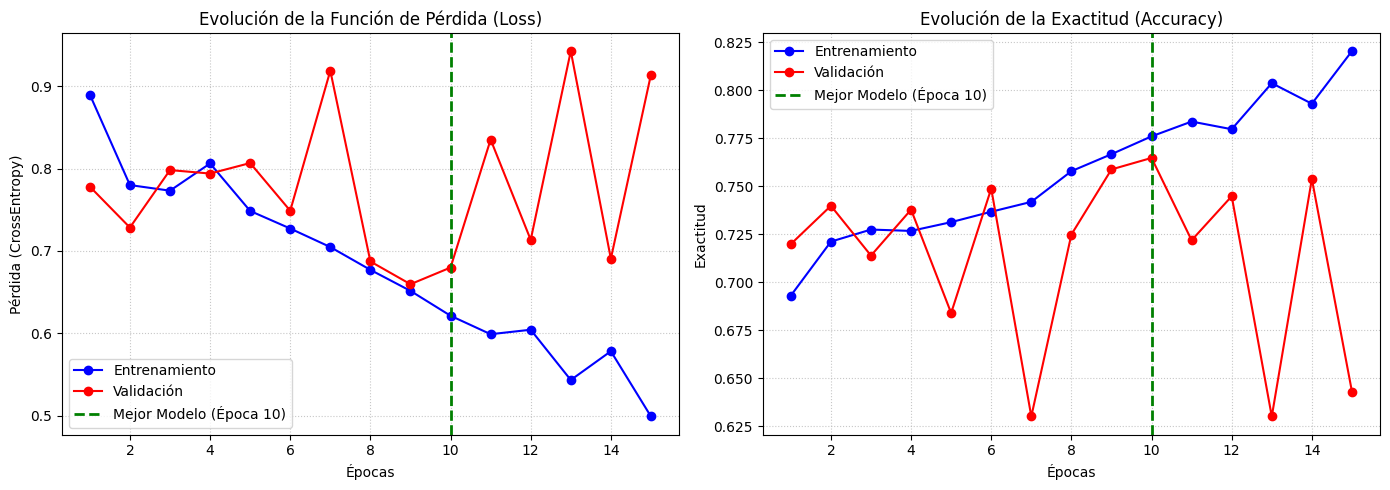

In [11]:
import matplotlib.pyplot as plt

# 1. Calculamos cuántas épocas corrieron realmente antes del Early Stopping
epocas_reales = range(1, len(historial_train_loss) + 1)

# 2. Encontramos en qué época se guardó el mejor modelo (nuestro récord)
# Como las listas en Python empiezan en 0, le sumamos 1
mejor_epoca = historial_val_acc.index(mejor_val_acc) + 1

# 3. Configuramos la figura con dos gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# GRÁFICO 1: FUNCIÓN DE PÉRDIDA (LOSS)
# ==========================================
ax1.plot(epocas_reales, historial_train_loss, label='Entrenamiento', color='blue', marker='o')
ax1.plot(epocas_reales, historial_val_loss, label='Validación', color='red', marker='o')

# Dibujamos una línea vertical para mostrar dónde se guardó el mejor modelo
ax1.axvline(x=mejor_epoca, color='green', linestyle='--', linewidth=2, label=f'Mejor Modelo (Época {mejor_epoca})')

ax1.set_title('Evolución de la Función de Pérdida (Loss)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Pérdida (CrossEntropy)')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)

# ==========================================
# GRÁFICO 2: EXACTITUD (ACCURACY)
# ==========================================
ax2.plot(epocas_reales, historial_train_acc, label='Entrenamiento', color='blue', marker='o')
ax2.plot(epocas_reales, historial_val_acc, label='Validación', color='red', marker='o')

# Línea vertical para el mejor modelo
ax2.axvline(x=mejor_epoca, color='green', linestyle='--', linewidth=2, label=f'Mejor Modelo (Época {mejor_epoca})')

ax2.set_title('Evolución de la Exactitud (Accuracy)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Exactitud')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.7)

# Mostramos el gráfico final
plt.tight_layout()
plt.show()

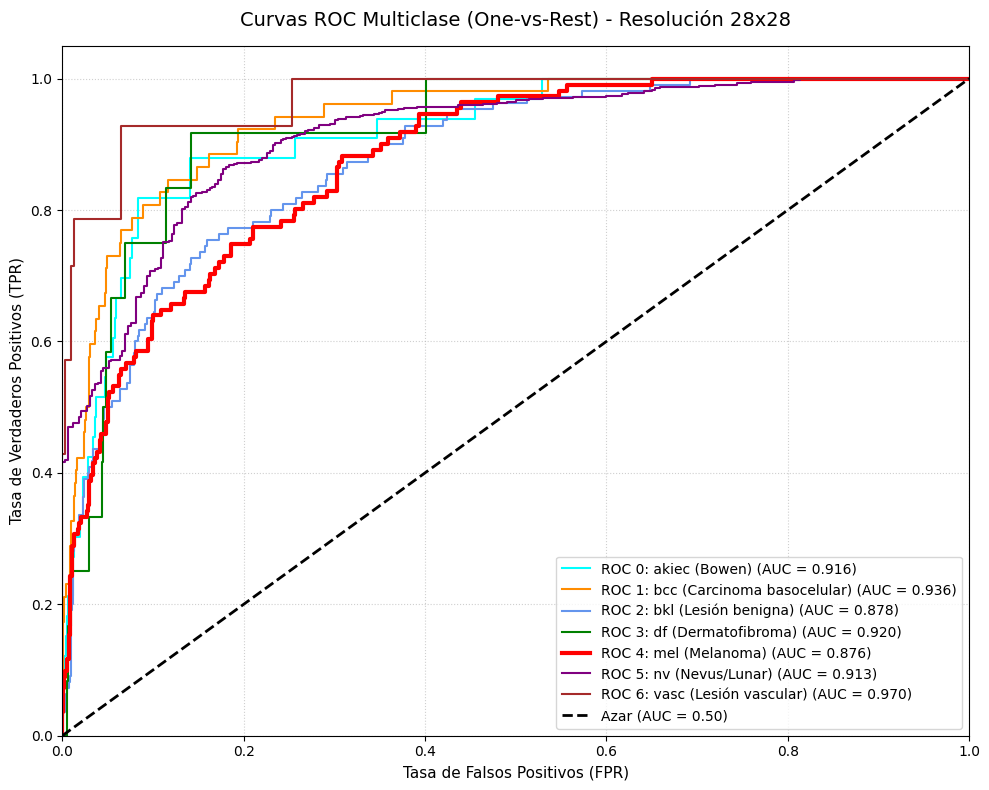

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Nombres de las 7 clases de DermaMNIST para la leyenda
nombres_clases = [
    '0: akiec (Bowen)', 
    '1: bcc (Carcinoma basocelular)', 
    '2: bkl (Lesión benigna)', 
    '3: df (Dermatofibroma)', 
    '4: mel (Melanoma)', 
    '5: nv (Nevus/Lunar)', 
    '6: vasc (Lesión vascular)'
]
n_clases = len(nombres_clases)

# 1. Binarizar las etiquetas verdaderas para el cálculo One-vs-Rest
# Convierte [0, 1, 4...] en matrices de ceros y unos
Y_bin = label_binarize(y_verdadero, classes=[0, 1, 2, 3, 4, 5, 6])

plt.figure(figsize=(10, 8))

# Paleta de colores para diferenciar bien las 7 curvas
colores = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown']

# 2. Calcular y graficar la curva ROC para cada una de las 7 enfermedades
for i, color in zip(range(n_clases), colores):
    # Calcula Tasa de Falsos Positivos (FPR) y Tasa de Verdaderos Positivos (TPR)
    fpr, tpr, umbrales = roc_curve(Y_bin[:, i], y_probabilidades[:, i])
    # Calcula el área bajo la curva específica para esta clase
    roc_auc = auc(fpr, tpr)
    
    # Destacar ligeramente la curva del Melanoma (clase 4) engrosando la línea
    grosor_linea = 3 if i == 4 else 1.5
    
    plt.plot(fpr, tpr, color=color, lw=grosor_linea,
             label=f'ROC {nombres_clases[i]} (AUC = {roc_auc:.3f})')

# 3. Dibujar la línea diagonal de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
plt.title('Curvas ROC Multiclase (One-vs-Rest) - Resolución 28x28', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()